## Step:1 Install libraries, Load and validate the dataset

In [3]:
# News EDA
# load and setup path and required libraries
!pip install pandas_market_calendars
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import pandas_market_calendars as mcal
import numpy as np

from datetime import timedelta
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Path: update this to match your local file location ────────────────────────
# By default this looks for main_news.parquet in the same folder as the notebook.
# Change to an absolute path if it lives elsewhere, e.g.:
#   path = r"C:\Users\you\data\main_news.parquet"
import pathlib
_nb_dir = pathlib.Path().resolve()
path = _nb_dir / "main_news.parquet"
# ───────────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(path)
# check the structure of the dataset
display(df.head())

# changing the data into dataframe
def create_dataframe(data):
    df = pd.DataFrame(data)
    return df

# create a dataframe from the loaded data
df = create_dataframe(df)
# check the structure of the dataframe
display(df)

# change the column sequence for better readability
df = df[["symbol","time_published", "overall_sentiment_score", "overall_sentiment_label","ticker_sentiment","title","topics","summary","url","authors","source","category_within_source","source_domain","banner_image"]]
# check the structure of the dataframe after changing the column sequence
display(df)

,title,url,time_published,authors,summary,banner_image,source,category_within_source,source_domain,topics,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,symbol
0,Blood-based gene expression signatures of medi...,https://www.nature.com/articles/srep18776,2016-01-05 05:51:32,"[Hiroaki Hori, Daimei Sasayama, Toshiya Terais...",This study investigates blood-based gene expre...,None,Nature,General,Nature,"[{'topic': 'life_sciences', 'relevance_score':...",0.122718,Neutral,"[{'ticker': 'A', 'relevance_score': '0.900629'...",A
1,Agilent accuses Twist Bioscience CEO of steali...,https://www.biopharmadive.com/news/agilent-acc...,2016-02-05 05:51:32,[Nicole Gray],Agilent Technologies has filed a lawsuit accus...,None,BioPharma Dive,General,BioPharma Dive,"[{'topic': 'life_sciences', 'relevance_score':...",-0.638520,Bearish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",A
2,Avago adopts new name,https://www.coloradoan.com/story/money/2016/02...,2016-02-16 05:51:32,[Adrian D. Garcia],"Avago Technologies, a major employer in Fort C...",None,The Coloradoan,General,The Coloradoan,"[{'topic': 'mergers_and_acquisitions', 'releva...",0.176532,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.603131'...",A
3,Nanotechnology Company Exicure Raises Over $42...,https://www.biospace.com/nanotechnology-compan...,2016-02-26 05:51:32,[Mark Terry],"Exicure, a nanotechnology company formerly kno...",None,BioSpace,General,BioSpace,"[{'topic': 'finance', 'relevance_score': '0.83...",0.299569,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.707012'...",A
4,Agilent Technologies introduces InfinityLab li...,https://www.newfoodmagazine.com/news/24382/agi...,2016-05-11 05:51:32,[Agilent Technologies Inc.],Agilent Technologies has introduced InfinityLa...,None,New Food magazine,General,New Food magazine,"[{'topic': 'life_sciences', 'relevance_score':...",0.426309,Bullish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",A


,title,url,time_published,authors,summary,banner_image,source,category_within_source,source_domain,topics,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,symbol
0,Blood-based gene expression signatures of medi...,https://www.nature.com/articles/srep18776,2016-01-05 05:51:32,"[Hiroaki Hori, Daimei Sasayama, Toshiya Terais...",This study investigates blood-based gene expre...,None,Nature,General,Nature,"[{'topic': 'life_sciences', 'relevance_score':...",0.122718,Neutral,"[{'ticker': 'A', 'relevance_score': '0.900629'...",A
1,Agilent accuses Twist Bioscience CEO of steali...,https://www.biopharmadive.com/news/agilent-acc...,2016-02-05 05:51:32,[Nicole Gray],Agilent Technologies has filed a lawsuit accus...,None,BioPharma Dive,General,BioPharma Dive,"[{'topic': 'life_sciences', 'relevance_score':...",-0.638520,Bearish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",A
2,Avago adopts new name,https://www.coloradoan.com/story/money/2016/02...,2016-02-16 05:51:32,[Adrian D. Garcia],"Avago Technologies, a major employer in Fort C...",None,The Coloradoan,General,The Coloradoan,"[{'topic': 'mergers_and_acquisitions', 'releva...",0.176532,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.603131'...",A
3,Nanotechnology Company Exicure Raises Over $42...,https://www.biospace.com/nanotechnology-compan...,2016-02-26 05:51:32,[Mark Terry],"Exicure, a nanotechnology company formerly kno...",None,BioSpace,General,BioSpace,"[{'topic': 'finance', 'relevance_score': '0.83...",0.299569,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.707012'...",A
4,Agilent Technologies introduces InfinityLab li...,https://www.newfoodmagazine.com/news/24382/agi...,2016-05-11 05:51:32,[Agilent Technologies Inc.],Agilent Technologies has introduced InfinityLa...,None,New Food magazine,General,New Food magazine,"[{'topic': 'life_sciences', 'relevance_score':...",0.426309,Bullish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770618,Boston Scientific (BSX) Stock After Hours on D...,https://ts2.tech/en/boston-scientific-bsx-stoc...,2025-12-25 03:08:20,[Khadija Saeed],Boston Scientific (NYSE: BSX) experienced a mo...,NULL,ts2.tech,General,ts2.tech,"[{'topic': 'financial_markets', 'relevance_sco...",0.184648,Somewhat-Bullish,"[{'ticker': 'BSX', 'relevance_score': '1.00000...",ZTS
770619,Yousif Capital Management LLC Boosts Stock Hol...,https://www.marketbeat.com/instant-alerts/fili...,2025-12-27 14:09:06,[MarketBeat],Yousif Capital Management LLC significantly in...,https://www.marketbeat.com/logos/elanco-animal...,MarketBeat,General,MarketBeat,"[{'topic': 'earnings', 'relevance_score': '0.9...",0.299451,Somewhat-Bullish,"[{'ticker': 'ELAN', 'relevance_score': '1.0000...",ZTS
770620,Zoetis (ZTS) Positioned Within Morgan Stanley’...,https://finance.yahoo.com/news/zoetis-zts-posi...,2025-12-28 02:17:00,[Vardah Gill],Zoetis Inc. (NYSE: ZTS) is included in Morgan ...,NULL,Yahoo Finance,General,Yahoo Finance,"[{'topic': 'life_sciences', 'relevance_score':...",0.104321,Neutral,"[{'ticker': 'MS', 'relevance_score': '0.739089...",ZTS
770621,Vertex Pharmaceuticals (NASDAQ:VRTX) Nasdaq in...,https://kalkinemedia.com/us/stocks/healthcare/...,2025-12-30 08:09:48,[Anmol Khazanchi],Vertex Pharmaceuticals (NASDAQ:VRTX) continues...,https://kalkinemedia.com/storage/uploads/thumb...,Kalkine Media,General,Kalkine Media,"[{'topic': 'life_sciences', 'relevance_score':...",0.284957,Somewhat-Bullish,"[{'ticker': 'VRTX', 'relevance_score': '1.0000...",ZTS


,symbol,time_published,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,title,topics,summary,url,authors,source,category_within_source,source_domain,banner_image
0,A,2016-01-05 05:51:32,0.122718,Neutral,"[{'ticker': 'A', 'relevance_score': '0.900629'...",Blood-based gene expression signatures of medi...,"[{'topic': 'life_sciences', 'relevance_score':...",This study investigates blood-based gene expre...,https://www.nature.com/articles/srep18776,"[Hiroaki Hori, Daimei Sasayama, Toshiya Terais...",Nature,General,Nature,None
1,A,2016-02-05 05:51:32,-0.638520,Bearish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",Agilent accuses Twist Bioscience CEO of steali...,"[{'topic': 'life_sciences', 'relevance_score':...",Agilent Technologies has filed a lawsuit accus...,https://www.biopharmadive.com/news/agilent-acc...,[Nicole Gray],BioPharma Dive,General,BioPharma Dive,None
2,A,2016-02-16 05:51:32,0.176532,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.603131'...",Avago adopts new name,"[{'topic': 'mergers_and_acquisitions', 'releva...","Avago Technologies, a major employer in Fort C...",https://www.coloradoan.com/story/money/2016/02...,[Adrian D. Garcia],The Coloradoan,General,The Coloradoan,None
3,A,2016-02-26 05:51:32,0.299569,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.707012'...",Nanotechnology Company Exicure Raises Over $42...,"[{'topic': 'finance', 'relevance_score': '0.83...","Exicure, a nanotechnology company formerly kno...",https://www.biospace.com/nanotechnology-compan...,[Mark Terry],BioSpace,General,BioSpace,None
4,A,2016-05-11 05:51:32,0.426309,Bullish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",Agilent Technologies introduces InfinityLab li...,"[{'topic': 'life_sciences', 'relevance_score':...",Agilent Technologies has introduced InfinityLa...,https://www.newfoodmagazine.com/news/24382/agi...,[Agilent Technologies Inc.],New Food magazine,General,New Food magazine,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770618,ZTS,2025-12-25 03:08:20,0.184648,Somewhat-Bullish,"[{'ticker': 'BSX', 'relevance_score': '1.00000...",Boston Scientific (BSX) Stock After Hours on D...,"[{'topic': 'financial_markets', 'relevance_sco...",Boston Scientific (NYSE: BSX) experienced a mo...,https://ts2.tech/en/boston-scientific-bsx-stoc...,[Khadija Saeed],ts2.tech,General,ts2.tech,NULL
770619,ZTS,2025-12-27 14:09:06,0.299451,Somewhat-Bullish,"[{'ticker': 'ELAN', 'relevance_score': '1.0000...",Yousif Capital Management LLC Boosts Stock Hol...,"[{'topic': 'earnings', 'relevance_score': '0.9...",Yousif Capital Management LLC significantly in...,https://www.marketbeat.com/instant-alerts/fili...,[MarketBeat],MarketBeat,General,MarketBeat,https://www.marketbeat.com/logos/elanco-animal...
770620,ZTS,2025-12-28 02:17:00,0.104321,Neutral,"[{'ticker': 'MS', 'relevance_score': '0.739089...",Zoetis (ZTS) Positioned Within Morgan Stanley’...,"[{'topic': 'life_sciences', 'relevance_score':...",Zoetis Inc. (NYSE: ZTS) is included in Morgan ...,https://finance.yahoo.com/news/zoetis-zts-posi...,[Vardah Gill],Yahoo Finance,General,Yahoo Finance,NULL
770621,ZTS,2025-12-30 08:09:48,0.284957,Somewhat-Bullish,"[{'ticker': 'VRTX', 'relevance_score': '1.0000...",Vertex Pharmaceuticals (NASDAQ:VRTX) Nasdaq in...,"[{'topic': 'life_sciences', 'relevance_score':...",Vertex Pharmaceuticals (NASDAQ:VRTX) continues...,https://kalkinemedia.com/us/stocks/healthcare/...,[Anmol Khazanchi],Kalkine Media,General,Kalkine Media,https://kalkinemedia.com/storage/uploads/thumb...


## Step:2 Market Aware data

In [4]:
# Build NYSE trading calendar once (covers full date range)
nyse = mcal.get_calendar("NYSE")
trading_days_set = set(
    nyse.valid_days(start_date="2016-01-01", end_date="2026-12-31")
    .normalize()
    .tz_localize(None)
    .date
)

def next_trading_day(d):
    """Walk forward day-by-day until we land on a valid NYSE trading day.
    Automatically skips: weekends + all NYSE holidays (Christmas, Thanksgiving, etc.)
    """
    candidate = d + timedelta(days=1)
    while candidate not in trading_days_set:
        candidate += timedelta(days=1)
    return candidate

# Convert time_published to ET so the 4 PM cutoff is timezone-correct
MARKET_CLOSE_HOUR = 16  # 4:00 PM ET

df["time_published"] = (
    pd.to_datetime(df["time_published"], utc=True)
    .dt.tz_convert("America/New_York")
)

# Core rule:
#   Before 4 PM ET  -> same day    (market was open, price already reacted)
#   4 PM ET or later -> next valid trading day (market closed, impact tomorrow)
df["date"] = df["time_published"].apply(
    lambda ts: next_trading_day(ts.date()) if ts.hour >= MARKET_CLOSE_HOUR else ts.date()
)

# Sanity Check
after_close  = (df["time_published"].dt.hour >= MARKET_CLOSE_HOUR).sum()
before_close = (df["time_published"].dt.hour <  MARKET_CLOSE_HOUR).sum()
invalid_dates = [d for d in df["date"].unique() if d not in trading_days_set]

print("Market-aware date assignment complete")
print(f"   Before 4 PM → same day          : {before_close:,}")
print(f"   After  4 PM → next trading day  : {after_close:,}")
print(f"   Dates landing on non-trading day : {len(invalid_dates)}")  # should be 0
df

Market-aware date assignment complete
   Before 4 PM → same day          : 541,345
   After  4 PM → next trading day  : 229,278
   Dates landing on non-trading day : 1095


,symbol,time_published,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,title,topics,summary,url,authors,source,category_within_source,source_domain,banner_image,date
0,A,2016-01-05 00:51:32-05:00,0.122718,Neutral,"[{'ticker': 'A', 'relevance_score': '0.900629'...",Blood-based gene expression signatures of medi...,"[{'topic': 'life_sciences', 'relevance_score':...",This study investigates blood-based gene expre...,https://www.nature.com/articles/srep18776,"[Hiroaki Hori, Daimei Sasayama, Toshiya Terais...",Nature,General,Nature,None,2016-01-05
1,A,2016-02-05 00:51:32-05:00,-0.638520,Bearish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",Agilent accuses Twist Bioscience CEO of steali...,"[{'topic': 'life_sciences', 'relevance_score':...",Agilent Technologies has filed a lawsuit accus...,https://www.biopharmadive.com/news/agilent-acc...,[Nicole Gray],BioPharma Dive,General,BioPharma Dive,None,2016-02-05
2,A,2016-02-16 00:51:32-05:00,0.176532,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.603131'...",Avago adopts new name,"[{'topic': 'mergers_and_acquisitions', 'releva...","Avago Technologies, a major employer in Fort C...",https://www.coloradoan.com/story/money/2016/02...,[Adrian D. Garcia],The Coloradoan,General,The Coloradoan,None,2016-02-16
3,A,2016-02-26 00:51:32-05:00,0.299569,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.707012'...",Nanotechnology Company Exicure Raises Over $42...,"[{'topic': 'finance', 'relevance_score': '0.83...","Exicure, a nanotechnology company formerly kno...",https://www.biospace.com/nanotechnology-compan...,[Mark Terry],BioSpace,General,BioSpace,None,2016-02-26
4,A,2016-05-11 01:51:32-04:00,0.426309,Bullish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",Agilent Technologies introduces InfinityLab li...,"[{'topic': 'life_sciences', 'relevance_score':...",Agilent Technologies has introduced InfinityLa...,https://www.newfoodmagazine.com/news/24382/agi...,[Agilent Technologies Inc.],New Food magazine,General,New Food magazine,None,2016-05-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770618,ZTS,2025-12-24 22:08:20-05:00,0.184648,Somewhat-Bullish,"[{'ticker': 'BSX', 'relevance_score': '1.00000...",Boston Scientific (BSX) Stock After Hours on D...,"[{'topic': 'financial_markets', 'relevance_sco...",Boston Scientific (NYSE: BSX) experienced a mo...,https://ts2.tech/en/boston-scientific-bsx-stoc...,[Khadija Saeed],ts2.tech,General,ts2.tech,NULL,2025-12-26
770619,ZTS,2025-12-27 09:09:06-05:00,0.299451,Somewhat-Bullish,"[{'ticker': 'ELAN', 'relevance_score': '1.0000...",Yousif Capital Management LLC Boosts Stock Hol...,"[{'topic': 'earnings', 'relevance_score': '0.9...",Yousif Capital Management LLC significantly in...,https://www.marketbeat.com/instant-alerts/fili...,[MarketBeat],MarketBeat,General,MarketBeat,https://www.marketbeat.com/logos/elanco-animal...,2025-12-27
770620,ZTS,2025-12-27 21:17:00-05:00,0.104321,Neutral,"[{'ticker': 'MS', 'relevance_score': '0.739089...",Zoetis (ZTS) Positioned Within Morgan Stanley’...,"[{'topic': 'life_sciences', 'relevance_score':...",Zoetis Inc. (NYSE: ZTS) is included in Morgan ...,https://finance.yahoo.com/news/zoetis-zts-posi...,[Vardah Gill],Yahoo Finance,General,Yahoo Finance,NULL,2025-12-29
770621,ZTS,2025-12-30 03:09:48-05:00,0.284957,Somewhat-Bullish,"[{'ticker': 'VRTX', 'relevance_score': '1.0000...",Vertex Pharmaceuticals (NASDAQ:VRTX) Nasdaq in...,"[{'topic': 'life_sciences', 'relevance_score':...",Vertex Pharmaceuticals (NASDAQ:VRTX) continues...,https://kalkinemedia.com/us/stocks/healthcare/...,[Anmol Khazanchi],Kalkine Media,General,Kalkine Media,https://kalkinemedia.com/storage/uploads/thumb...,2025-12-30


In [5]:
# Rename Alpha Vantage columns to pipeline-friendly names
df = df.rename(columns={
    "title"   : "headline",
    "summary" : "content",
    "symbol"  : "ticker",
})

# Swap the time_published and date columns for better readability
df = df[["ticker", "date", "overall_sentiment_score", "overall_sentiment_label", "ticker_sentiment", "headline", "topics", "content", "url", "authors", "source", "category_within_source", "source_domain", "banner_image","time_published"]]
df

,ticker,date,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,headline,topics,content,url,authors,source,category_within_source,source_domain,banner_image,time_published
0,A,2016-01-05,0.122718,Neutral,"[{'ticker': 'A', 'relevance_score': '0.900629'...",Blood-based gene expression signatures of medi...,"[{'topic': 'life_sciences', 'relevance_score':...",This study investigates blood-based gene expre...,https://www.nature.com/articles/srep18776,"[Hiroaki Hori, Daimei Sasayama, Toshiya Terais...",Nature,General,Nature,None,2016-01-05 00:51:32-05:00
1,A,2016-02-05,-0.638520,Bearish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",Agilent accuses Twist Bioscience CEO of steali...,"[{'topic': 'life_sciences', 'relevance_score':...",Agilent Technologies has filed a lawsuit accus...,https://www.biopharmadive.com/news/agilent-acc...,[Nicole Gray],BioPharma Dive,General,BioPharma Dive,None,2016-02-05 00:51:32-05:00
2,A,2016-02-16,0.176532,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.603131'...",Avago adopts new name,"[{'topic': 'mergers_and_acquisitions', 'releva...","Avago Technologies, a major employer in Fort C...",https://www.coloradoan.com/story/money/2016/02...,[Adrian D. Garcia],The Coloradoan,General,The Coloradoan,None,2016-02-16 00:51:32-05:00
3,A,2016-02-26,0.299569,Somewhat-Bullish,"[{'ticker': 'A', 'relevance_score': '0.707012'...",Nanotechnology Company Exicure Raises Over $42...,"[{'topic': 'finance', 'relevance_score': '0.83...","Exicure, a nanotechnology company formerly kno...",https://www.biospace.com/nanotechnology-compan...,[Mark Terry],BioSpace,General,BioSpace,None,2016-02-26 00:51:32-05:00
4,A,2016-05-11,0.426309,Bullish,"[{'ticker': 'A', 'relevance_score': '1.000000'...",Agilent Technologies introduces InfinityLab li...,"[{'topic': 'life_sciences', 'relevance_score':...",Agilent Technologies has introduced InfinityLa...,https://www.newfoodmagazine.com/news/24382/agi...,[Agilent Technologies Inc.],New Food magazine,General,New Food magazine,None,2016-05-11 01:51:32-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770618,ZTS,2025-12-26,0.184648,Somewhat-Bullish,"[{'ticker': 'BSX', 'relevance_score': '1.00000...",Boston Scientific (BSX) Stock After Hours on D...,"[{'topic': 'financial_markets', 'relevance_sco...",Boston Scientific (NYSE: BSX) experienced a mo...,https://ts2.tech/en/boston-scientific-bsx-stoc...,[Khadija Saeed],ts2.tech,General,ts2.tech,NULL,2025-12-24 22:08:20-05:00
770619,ZTS,2025-12-27,0.299451,Somewhat-Bullish,"[{'ticker': 'ELAN', 'relevance_score': '1.0000...",Yousif Capital Management LLC Boosts Stock Hol...,"[{'topic': 'earnings', 'relevance_score': '0.9...",Yousif Capital Management LLC significantly in...,https://www.marketbeat.com/instant-alerts/fili...,[MarketBeat],MarketBeat,General,MarketBeat,https://www.marketbeat.com/logos/elanco-animal...,2025-12-27 09:09:06-05:00
770620,ZTS,2025-12-29,0.104321,Neutral,"[{'ticker': 'MS', 'relevance_score': '0.739089...",Zoetis (ZTS) Positioned Within Morgan Stanley’...,"[{'topic': 'life_sciences', 'relevance_score':...",Zoetis Inc. (NYSE: ZTS) is included in Morgan ...,https://finance.yahoo.com/news/zoetis-zts-posi...,[Vardah Gill],Yahoo Finance,General,Yahoo Finance,NULL,2025-12-27 21:17:00-05:00
770621,ZTS,2025-12-30,0.284957,Somewhat-Bullish,"[{'ticker': 'VRTX', 'relevance_score': '1.0000...",Vertex Pharmaceuticals (NASDAQ:VRTX) Nasdaq in...,"[{'topic': 'life_sciences', 'relevance_score':...",Vertex Pharmaceuticals (NASDAQ:VRTX) continues...,https://kalkinemedia.com/us/stocks/healthcare/...,[Anmol Khazanchi],Kalkine Media,General,Kalkine Media,https://kalkinemedia.com/storage/uploads/thumb...,2025-12-30 03:09:48-05:00


In [6]:
# dropping the unnecessary columns
df = df.drop(columns=[
    "banner_image",           # image URL, zero analytical value
    "category_within_source", # too granular, not used anywhere
    "source_domain",          # duplicate of source (just the domain part)
    "url",                    # article link, not a feature
    "authors",                # not used in any aggregation
])

## Step:3 Article level EDA

In [7]:
print("Missing Values per Column")
print(df.isnull().sum())

print("\nArticles per Ticker (Top 10)")
print(df["ticker"].value_counts().head(10))

print("\nArticles per Day (stats)")
print(df.groupby("date").size().describe().round(2))

print("\nSentiment Label Distribution")
print(df["overall_sentiment_label"].value_counts())

Missing Values per Column
ticker                       0
date                         0
overall_sentiment_score      0
overall_sentiment_label      0
ticker_sentiment             0
headline                     0
topics                       0
content                    236
source                       0
time_published               0
dtype: int64

Articles per Ticker (Top 10)
ticker
JPM      19325
MSFT     15082
NVDA     14558
AMZN     13307
MS       10740
BAC       9725
GOOGL     9145
GS        8984
WFC       8808
AAPL      8677
Name: count, dtype: int64

Articles per Day (stats)
count     3610.00
mean       213.47
std        826.77
min          1.00
25%         26.00
50%         75.50
75%        216.00
max      18881.00
dtype: float64

Sentiment Label Distribution
overall_sentiment_label
Somewhat-Bullish    291287
Neutral             215733
Bullish             174662
Somewhat-Bearish     52299
Bearish              36642
Name: count, dtype: int64


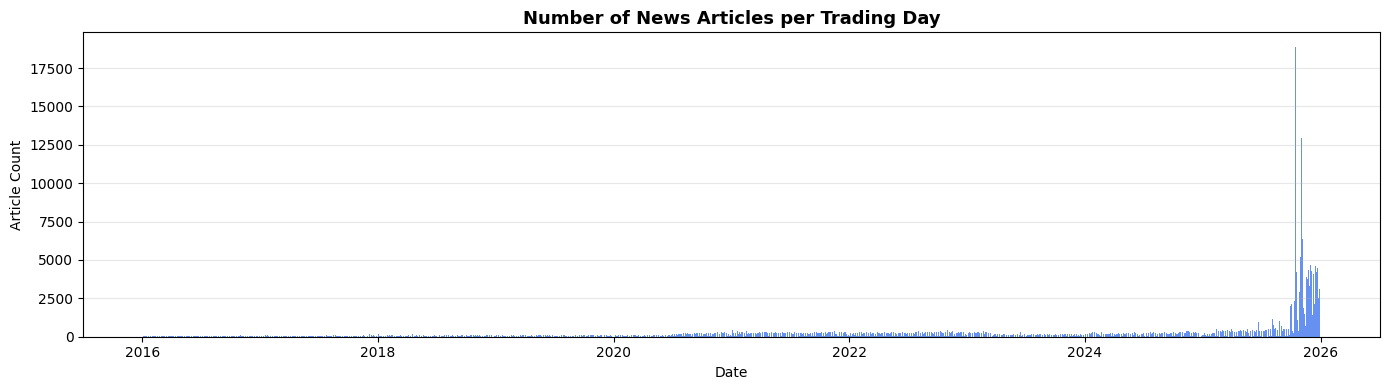

In [8]:
# Articles over time
daily_count = df.groupby("date").size().reset_index(name="count")
daily_count["date"] = pd.to_datetime(daily_count["date"])

plt.figure(figsize=(14, 4))
plt.bar(daily_count["date"], daily_count["count"], color="#2563EB", alpha=0.7, width=1)
plt.title("Number of News Articles per Trading Day", fontsize=13, fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Article Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

/tmp/ipykernel_653/3360985998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tickers.index, y=top_tickers.values, palette="Blues_r")


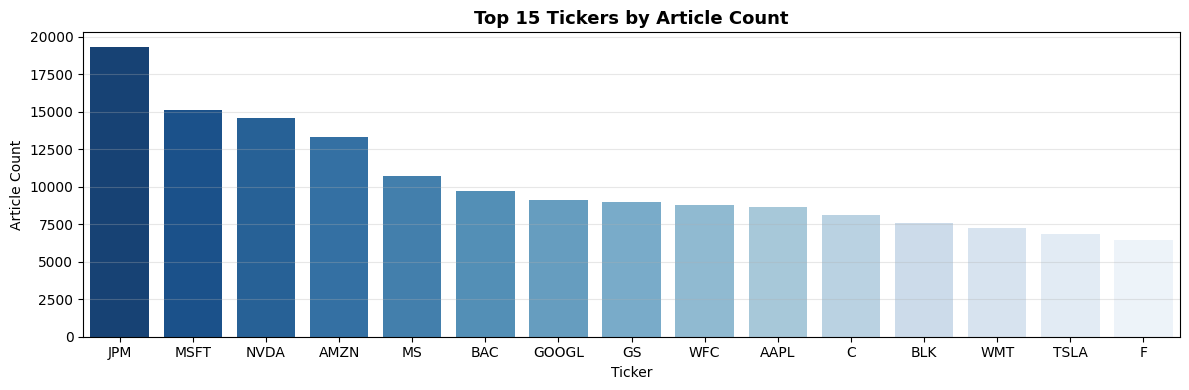

In [9]:
# Top 15 tickers by article count
top_tickers = df["ticker"].value_counts().head(15)

plt.figure(figsize=(12, 4))
sns.barplot(x=top_tickers.index, y=top_tickers.values, palette="Blues_r")
plt.title("Top 15 Tickers by Article Count", fontsize=13, fontweight="bold")
plt.xlabel("Ticker"); plt.ylabel("Article Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

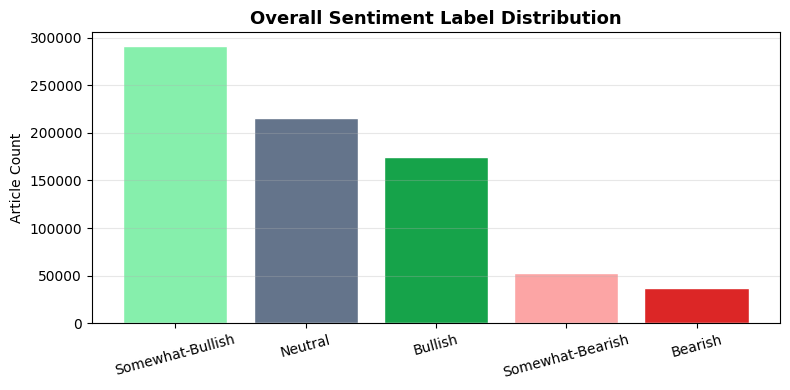

In [10]:
# Sentiment label distribution bar chart (using your actual labels)
label_counts = df["overall_sentiment_label"].value_counts()
colors_map   = {
    "Bullish"          : "#16a34a",
    "Somewhat-Bullish" : "#86efac",
    "Neutral"          : "#64748b",
    "Somewhat-Bearish" : "#fca5a5",
    "Bearish"          : "#dc2626",
}
bar_colors = [colors_map.get(l, "#94a3b8") for l in label_counts.index]

plt.figure(figsize=(8, 4))
plt.bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor="white")
plt.title("Overall Sentiment Label Distribution", fontsize=13, fontweight="bold")
plt.ylabel("Article Count")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

/tmp/ipykernel_653/3704235678.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette="muted")


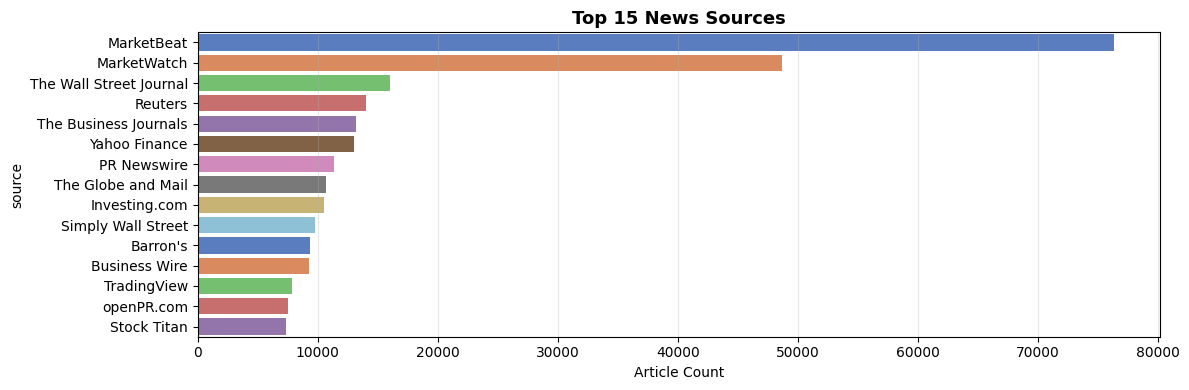

In [11]:
# News source distribution (Top 15)
top_sources = df["source"].value_counts().head(15)

plt.figure(figsize=(12, 4))
sns.barplot(x=top_sources.values, y=top_sources.index, palette="muted")
plt.title("Top 15 News Sources", fontsize=13, fontweight="bold")
plt.xlabel("Article Count")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

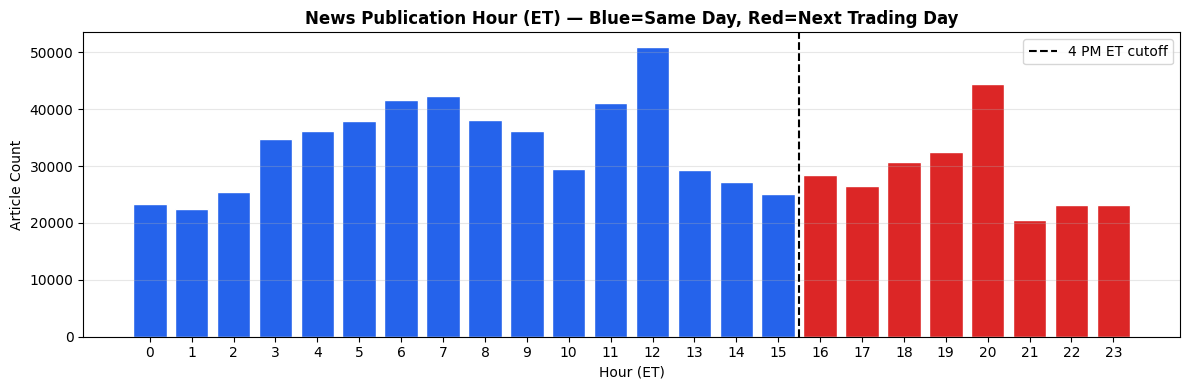

In [12]:
# Hour-of-day distribution (ET) — shows when news is published
df["hour_et"] = df["time_published"].dt.hour

plt.figure(figsize=(12, 4))
hour_counts = df["hour_et"].value_counts().sort_index()
colors_hour = ["#dc2626" if h >= 16 else "#2563EB" for h in hour_counts.index]
plt.bar(hour_counts.index, hour_counts.values, color=colors_hour, edgecolor="white")
plt.axvline(15.5, color="black", linestyle="--", linewidth=1.5, label="4 PM ET cutoff")
plt.title("News Publication Hour (ET) — Blue=Same Day, Red=Next Trading Day",
          fontsize=12, fontweight="bold")
plt.xlabel("Hour (ET)"); plt.ylabel("Article Count")
plt.xticks(range(0, 24))
plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

df = df.drop(columns=["hour_et"])  # temp column cleanup

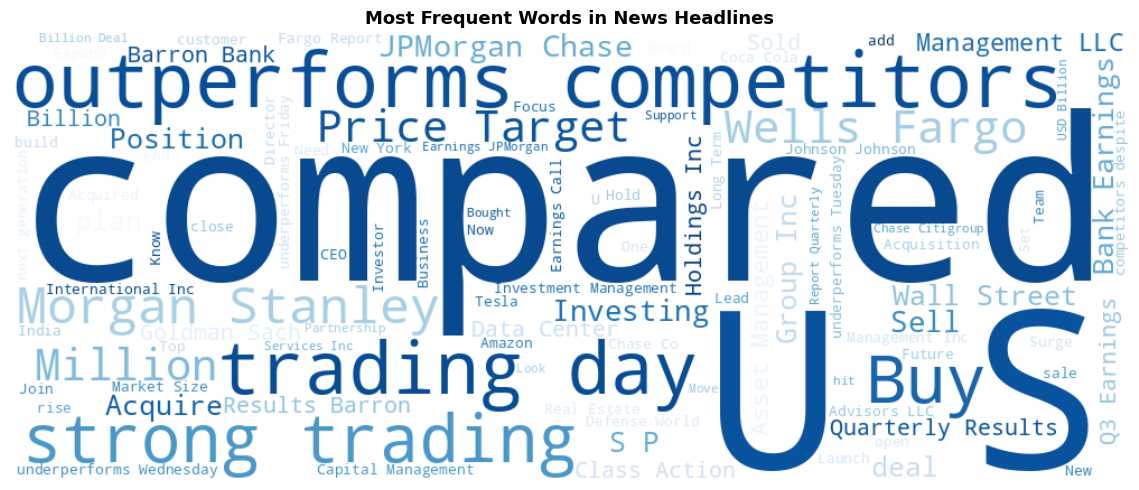

In [13]:
# Headline word cloud
df = df.dropna(subset=["headline"]).reset_index(drop=True)

text = " ".join(df["headline"].dropna().tolist())
stopwords = set(STOPWORDS) | {"says", "will", "stock", "shares", "company", "year"}

wc = WordCloud(width=1000, height=400, background_color="white",
               stopwords=stopwords, colormap="Blues", max_words=100).generate(text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in News Headlines", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Step:4 Derive sentiment score columns

> **Why keep `positive`, `negative`, `neutral` when you already have `overall_sentiment_label`?**  
> - `overall_sentiment_label` is a **categorical string** (Bullish/Bearish/etc.) - can't be averaged or rolled  
> - `positive` / `negative` / `neutral` are **continuous floats** derived from the numeric score - used in daily ratios, rolling pressure, lag features  
> - Both are kept: label -> `Dominant_Sentiment_Label` in daily agg; floats -> all rolling/aggregation features

In [14]:
# compound = the raw score from Alpha Vantage
df["compound"] = df["overall_sentiment_score"]

# Continuous proxies - used in daily aggregation & rolling features
df["positive"] = df["compound"].clip(lower=0)       # positive intensity
df["negative"] = (-df["compound"]).clip(lower=0)    # negative intensity
df["neutral"]  = 1 - df["positive"] - df["negative"] # residual

print("Sentiment score columns derived")
print(f"   Avg compound score  : {df['compound'].mean():.4f}")
print(f"   % Positive articles : {(df['compound'] > 0).mean()*100:.1f}%")
print(f"   % Negative articles : {(df['compound'] < 0).mean()*100:.1f}%")
display(df[["headline", "overall_sentiment_label", "compound", "positive", "negative", "neutral"]].head(6))

Sentiment score columns derived
   Avg compound score  : 0.1721
   % Positive articles : 82.6%
   % Negative articles : 17.4%


,headline,overall_sentiment_label,compound,positive,negative,neutral
0,Blood-based gene expression signatures of medi...,Neutral,0.122718,0.122718,0.00000,0.877282
1,Agilent accuses Twist Bioscience CEO of steali...,Bearish,-0.638520,0.000000,0.63852,0.361480
2,Avago adopts new name,Somewhat-Bullish,0.176532,0.176532,0.00000,0.823468
3,Nanotechnology Company Exicure Raises Over $42...,Somewhat-Bullish,0.299569,0.299569,0.00000,0.700431
4,Agilent Technologies introduces InfinityLab li...,Bullish,0.426309,0.426309,0.00000,0.573691
5,The minimal amount of starting DNA for Agilent...,Somewhat-Bullish,0.278474,0.278474,0.00000,0.721526


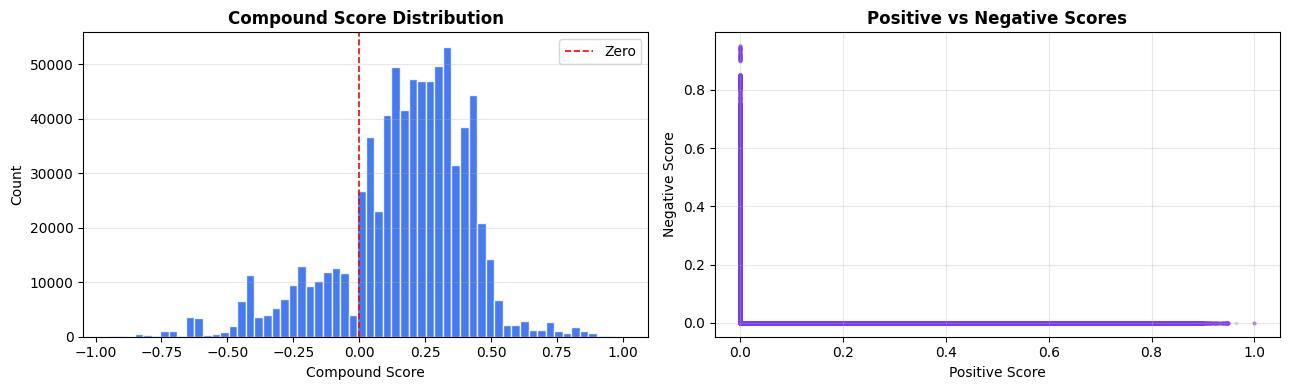

In [15]:
# Compound score distribution + positive vs negative scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["compound"], bins=60, color="#2563EB", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero")
axes[0].set_title("Compound Score Distribution", fontweight="bold")
axes[0].set_xlabel("Compound Score"); axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

axes[1].scatter(df["positive"], df["negative"], alpha=0.15, s=4, color="#7c3aed")
axes[1].set_xlabel("Positive Score"); axes[1].set_ylabel("Negative Score")
axes[1].set_title("Positive vs Negative Scores", fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step:5 Extract Ticker_sentiment & topics

In [16]:
# 5a: ticker_sentiment - per-ticker relevance & sentiment score inside each article
import ast, json

# Toggle: group daily aggregates by ticker (True) or market-wide only (False)
GROUP_BY_TICKER = True

def extract_ticker_sentiment(row):
    # handle numpy arrays first
    if isinstance(row, np.ndarray):
        if row.size == 0:
            return pd.DataFrame()
        items = row.tolist()
    else:
        if pd.isna(row):
            return pd.DataFrame()
        if isinstance(row, (bytes, bytearray)):
            row = row.decode(errors='replace')
        if isinstance(row, str):
            s = row.strip()
            if s in ('', '[]', 'null', 'None'):
                return pd.DataFrame()
            try:
                items = ast.literal_eval(row)
            except Exception:
                try:
                    items = json.loads(row)
                except Exception:
                    return pd.DataFrame()
        else:
            items = row

    if isinstance(items, dict):
        items = [items]
    if isinstance(items, list) and items:
        items = [it if isinstance(it, dict) else {} for it in items]
        return pd.DataFrame(items)
    return pd.DataFrame()

ts_rows = []
for idx, row in df.iterrows():
    parsed = extract_ticker_sentiment(row["ticker_sentiment"])
    if not parsed.empty:
        for _, r in parsed.iterrows():
            ts_rows.append({
                "date"                   : df.at[idx, "date"],
                "ticker"                 : r.get("ticker", ""),
                "ticker_relevance_score" : float(r.get("relevance_score", 0)),
                "ticker_sentiment_score" : float(r.get("ticker_sentiment_score", 0)),
                "ticker_sentiment_label" : r.get("ticker_sentiment_label", ""),
            })

df_ticker_sent = pd.DataFrame(ts_rows)
print(f"Extracted {len(df_ticker_sent):,} ticker-level sentiment rows")
if not df_ticker_sent.empty and 'ticker' in df_ticker_sent.columns:
    print(f"   Unique tickers : {df_ticker_sent['ticker'].nunique()}")
    print("\nTicker Sentiment Label Distribution")
    print(df_ticker_sent["ticker_sentiment_label"].value_counts())
    display(df_ticker_sent.head(5))
else:
    print("No ticker_sentiment rows extracted")
    display(df_ticker_sent.head(0))

Extracted 2,040,433 ticker-level sentiment rows
   Unique tickers : 9794

Ticker Sentiment Label Distribution
ticker_sentiment_label
Neutral             753432
Somewhat-Bullish    688165
Bullish             384138
Somewhat-Bearish    140857
Bearish              73841
Name: count, dtype: int64


,date,ticker,ticker_relevance_score,ticker_sentiment_score,ticker_sentiment_label
0,2016-01-05,A,0.900629,0.101134,Neutral
1,2016-02-05,A,1.000000,-0.639674,Bearish
2,2016-02-16,A,0.603131,-0.119860,Neutral
3,2016-02-16,AVGO,1.000000,0.440914,Bullish
4,2016-02-26,A,0.707012,0.339568,Somewhat-Bullish


In [17]:
# 5b: topics - pivot top-10 topics into relevance score features
topic_rows = []
for idx, row in df.iterrows():
    try:
        items = row["topics"]

        if isinstance(items, np.ndarray):
            items = items.tolist()

        if isinstance(items, str):
            try:
                items = ast.literal_eval(items)
            except Exception:
                try:
                    items = json.loads(items)
                except Exception:
                    items = []

        if isinstance(items, dict):
            items = [items]

        if isinstance(items, list):
            for t in items:
                if isinstance(t, dict):
                    topic_rows.append({
                        "date": df.at[idx, "date"],
                        "ticker": df.at[idx, "ticker"],
                        "topic": t.get("topic", ""),
                        "relevance_score": float(t.get("relevance_score", 0)),
                    })
    except Exception:
        pass

df_topics = pd.DataFrame(topic_rows)

if df_topics.empty:
    print("No topics extracted")
    topic_pivot = pd.DataFrame(columns=["date", "ticker"])
else:
    top_topics = df_topics["topic"].value_counts().head(10).index.tolist()
    print(f"Top 10 topics: {top_topics}")

    topic_pivot = (
        df_topics[df_topics["topic"].isin(top_topics)]
        .pivot_table(
            index=["date", "ticker"],
            columns="topic",
            values="relevance_score",
            aggfunc="mean",
        )
        .fillna(0)
        .reset_index()
    )
    topic_pivot.columns.name = None
    print(f"Topic feature shape: {topic_pivot.shape}")
    display(topic_pivot.head(10))

Top 10 topics: ['financial_markets', 'finance', 'earnings', 'technology', 'economy_macro', 'energy_transportation', 'retail_wholesale', 'life_sciences', 'manufacturing', 'mergers_and_acquisitions']
Topic feature shape: (300378, 12)


,date,ticker,earnings,economy_macro,energy_transportation,finance,financial_markets,life_sciences,manufacturing,mergers_and_acquisitions,retail_wholesale,technology
0,2016-01-01,AAPL,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.841959
1,2016-01-01,KHC,0.940419,0.000000,0.000000,0.000000,0.613986,0.0,0.000000,0.816794,0.616715,0.000000
2,2016-01-01,LMT,0.000000,0.000000,0.869031,0.000000,0.000000,0.0,0.772564,0.000000,0.000000,0.000000
3,2016-01-02,LVS,0.000000,0.000000,0.000000,0.637024,0.000000,0.0,0.000000,0.803929,0.000000,0.000000
4,2016-01-03,FANG,0.000000,0.633938,0.913492,0.812847,0.712879,0.0,0.000000,0.000000,0.000000,0.000000
5,2016-01-03,NOC,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.905226,0.000000,0.000000,0.000000
6,2016-01-04,AAPL,0.000000,0.000000,0.729943,0.832850,0.000000,0.0,0.000000,0.932805,0.843914,0.713010
7,2016-01-04,ACGL,0.000000,0.000000,0.000000,0.819011,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
8,2016-01-04,AEE,0.000000,0.000000,0.945368,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
9,2016-01-04,AIG,0.000000,0.000000,0.000000,0.841976,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


/tmp/ipykernel_653/3347846406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_freq.values, y=topic_freq.index, palette="Blues_r")


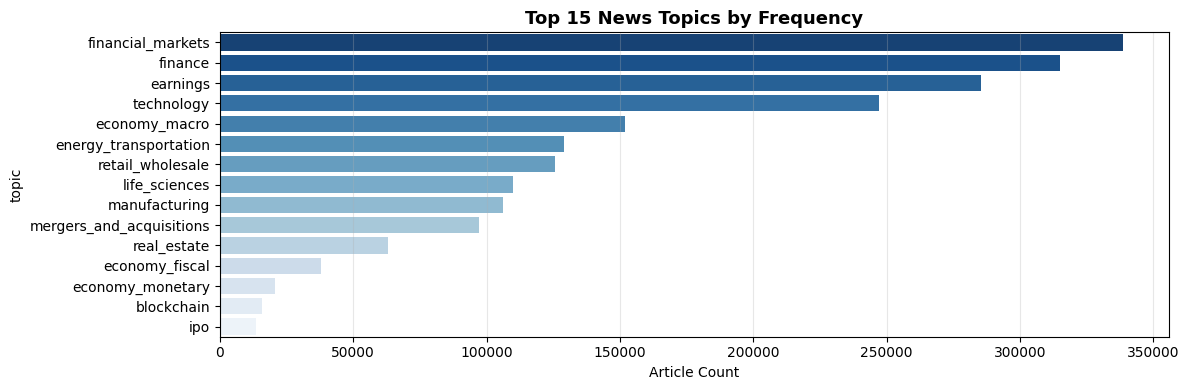

In [18]:
# Topic frequency bar chart
topic_freq = df_topics["topic"].value_counts().head(15)

plt.figure(figsize=(12, 4))
sns.barplot(x=topic_freq.values, y=topic_freq.index, palette="Blues_r")
plt.title("Top 15 News Topics by Frequency", fontsize=13, fontweight="bold")
plt.xlabel("Article Count")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## Step:6 Daily Aggregation

In [19]:
# Always group by both date AND ticker to preserve per-ticker granularity
GROUP_BY_TICKER = True
group_keys = ["date", "ticker"]

daily = df.groupby(group_keys).agg(
    News_Count               = ("compound", "count"),
    Daily_Avg_Sentiment      = ("compound", "mean"),
    Daily_Sentiment_Std      = ("compound", "std"),
    Positive_Ratio           = ("positive", "mean"),
    Negative_Ratio           = ("negative", "mean"),
    Neutral_Ratio            = ("neutral",  "mean"),
    Max_Positive             = ("positive", "max"),
    Max_Negative             = ("negative", "max"),
    Sentiment_Range          = ("compound", lambda x: x.max() - x.min()),
    Dominant_Sentiment_Label = ("overall_sentiment_label",
                                lambda x: x.mode()[0] if len(x) > 0 else "Neutral"),
).reset_index()

daily["Daily_Sentiment_Std"] = daily["Daily_Sentiment_Std"].fillna(0)

# ── Snapshot the merge keys so we can restore them if a merge drops them ──────
_ticker_snap = daily["ticker"].copy()
_date_snap   = daily["date"].copy()

# Merge ticker-level relevance/sentiment scores
if not df_ticker_sent.empty and "ticker" in df_ticker_sent.columns:
    ticker_daily = df_ticker_sent.groupby(["date", "ticker"]).agg(
        Avg_Ticker_Relevance = ("ticker_relevance_score", "mean"),
        Avg_Ticker_Sentiment = ("ticker_sentiment_score", "mean"),
    ).reset_index()
    daily = pd.merge(daily, ticker_daily, on=["date", "ticker"], how="left")
else:
    daily["Avg_Ticker_Relevance"] = 0.0
    daily["Avg_Ticker_Sentiment"] = 0.0

# Merge topic features
if not topic_pivot.empty and "ticker" in topic_pivot.columns:
    # Flatten any MultiIndex columns that pivot_table may have created
    topic_pivot.columns = [str(c) for c in topic_pivot.columns]
    topic_pivot = topic_pivot.reset_index(drop=False) if "ticker" not in topic_pivot.columns else topic_pivot
    daily = pd.merge(daily, topic_pivot, on=["date", "ticker"], how="left")

# ── Restore ticker/date if any merge accidentally dropped them ─────────────────
if "ticker" not in daily.columns:
    daily.insert(0, "ticker", _ticker_snap.values)
if "date" not in daily.columns:
    daily.insert(1, "date", _date_snap.values)

# fillna(0) only on numeric columns — never touch string columns
_str_cols = ["ticker", "date", "Dominant_Sentiment_Label"]
_num_cols  = [c for c in daily.columns if c not in _str_cols]
daily[_num_cols] = daily[_num_cols].fillna(0)

# Remove any duplicate columns from repeated runs
daily = daily.loc[:, ~daily.columns.duplicated()]

assert "ticker" in daily.columns, "ticker column missing after aggregation!"
assert "date"   in daily.columns, "date column missing after aggregation!"

print(f"Daily aggregation complete : {len(daily):,} rows x {daily.shape[1]} columns")
print(f"   Unique tickers          : {daily['ticker'].nunique()}")
print(f"   Date range              : {daily['date'].min()} → {daily['date'].max()}")
display(daily[["ticker", "date"] + [c for c in daily.columns if c not in ["ticker", "date"]]].head(6))

Daily aggregation complete : 303,288 rows x 24 columns
   Unique tickers          : 500
   Date range              : 2016-01-01 → 2026-01-02


,ticker,date,News_Count,Daily_Avg_Sentiment,Daily_Sentiment_Std,Positive_Ratio,Negative_Ratio,Neutral_Ratio,Max_Positive,Max_Negative,...,earnings,economy_macro,energy_transportation,finance,financial_markets,life_sciences,manufacturing,mergers_and_acquisitions,retail_wholesale,technology
0,AAPL,2016-01-01,1,0.345587,0.000000,0.345587,0.000000,0.654413,0.345587,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.841959
1,AEE,2016-01-01,1,-0.202165,0.000000,0.000000,0.202165,0.797835,0.000000,0.202165,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
2,AVB,2016-01-01,1,0.405956,0.000000,0.405956,0.000000,0.594044,0.405956,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
3,KHC,2016-01-01,1,0.018551,0.000000,0.018551,0.000000,0.981449,0.018551,0.000000,...,0.940419,0.0,0.000000,0.000000,0.613986,0.0,0.000000,0.816794,0.616715,0.000000
4,LMT,2016-01-01,2,0.420951,0.003533,0.420951,0.000000,0.579049,0.423449,0.000000,...,0.000000,0.0,0.869031,0.000000,0.000000,0.0,0.772564,0.000000,0.000000,0.000000
5,LVS,2016-01-02,1,0.141953,0.000000,0.141953,0.000000,0.858047,0.141953,0.000000,...,0.000000,0.0,0.000000,0.637024,0.000000,0.0,0.000000,0.803929,0.000000,0.000000


## Step:7 Lag & Rolling Features

In [20]:
# Add lagged features, rolling means, and momentum indicators
daily["date"] = pd.to_datetime(daily["date"])

# Self-heal: if ticker ended up in the index instead of columns, bring it back
if "ticker" not in daily.columns and daily.index.name == "ticker":
    daily = daily.reset_index()
if "ticker" not in daily.columns:
    raise RuntimeError(
        "ticker column is missing from daily.\n"
        "Please re-run Step 6 (Daily Aggregation) then re-run this cell."
    )

daily = daily.sort_values(["ticker", "date"] if GROUP_BY_TICKER else ["date"])

def add_lags(grp):
    grp = grp.copy()
    s = grp["Daily_Avg_Sentiment"]
    grp["Sentiment_Lag1"]     = s.shift(1)
    grp["Sentiment_Lag2"]     = s.shift(2)
    grp["Sentiment_Lag3"]     = s.shift(3)
    grp["Sentiment_MA3"]      = s.rolling(3).mean()
    grp["Sentiment_MA5"]      = s.rolling(5).mean()
    grp["Sentiment_Momentum"] = s - grp["Sentiment_MA3"]
    grp["Sentiment_Trend"]    = (s > s.shift(1)).astype(int)
    grp["NewsCount_Lag1"]     = grp["News_Count"].shift(1)
    grp["Neg_Pressure_3d"]    = grp["Negative_Ratio"].rolling(3).mean()
    return grp

if GROUP_BY_TICKER:
    daily = (
        daily
        .groupby("ticker", group_keys=False)
        .apply(add_lags)
        .reset_index(drop=True)
    )
    daily = daily.loc[:, ~daily.columns.duplicated()]
else:
    daily = add_lags(daily).reset_index(drop=True)

# Restore ticker if pandas pushed it into the index during apply
if "ticker" not in daily.columns:
    daily = daily.reset_index()
    daily = daily.loc[:, ~daily.columns.duplicated()]

id_cols   = ["date", "ticker"] if GROUP_BY_TICKER else ["date"]
non_feat  = id_cols + ["Dominant_Sentiment_Label"]
feat_cols = [c for c in daily.columns if c not in non_feat]

assert "ticker" in daily.columns, "ticker missing after lag step"

print(f"Lag & rolling features added")
print(f"   Total numeric features: {len(feat_cols)}")
display(daily.head(5))

Lag & rolling features added
   Total numeric features: 30


/tmp/ipykernel_653/4246639794.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_lags)


,date,ticker,News_Count,Daily_Avg_Sentiment,Daily_Sentiment_Std,Positive_Ratio,Negative_Ratio,Neutral_Ratio,Max_Positive,Max_Negative,...,technology,Sentiment_Lag1,Sentiment_Lag2,Sentiment_Lag3,Sentiment_MA3,Sentiment_MA5,Sentiment_Momentum,Sentiment_Trend,NewsCount_Lag1,Neg_Pressure_3d
0,2016-01-05,A,1,0.122718,0.0,0.122718,0.00000,0.877282,0.122718,0.00000,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,2016-02-05,A,1,-0.638520,0.0,0.000000,0.63852,0.361480,0.000000,0.63852,...,0.833628,0.122718,NaN,NaN,NaN,NaN,NaN,0,1.0,NaN
2,2016-02-16,A,1,0.176532,0.0,0.176532,0.00000,0.823468,0.176532,0.00000,...,0.813530,-0.638520,0.122718,NaN,-0.113090,NaN,0.289622,1,1.0,0.21284
3,2016-02-26,A,1,0.299569,0.0,0.299569,0.00000,0.700431,0.299569,0.00000,...,0.831460,0.176532,-0.638520,0.122718,-0.054140,NaN,0.353709,1,1.0,0.21284
4,2016-05-11,A,1,0.426309,0.0,0.426309,0.00000,0.573691,0.426309,0.00000,...,0.729947,0.299569,0.176532,-0.638520,0.300803,0.077322,0.125506,1,1.0,0.00000


## Step:8 Visualizations

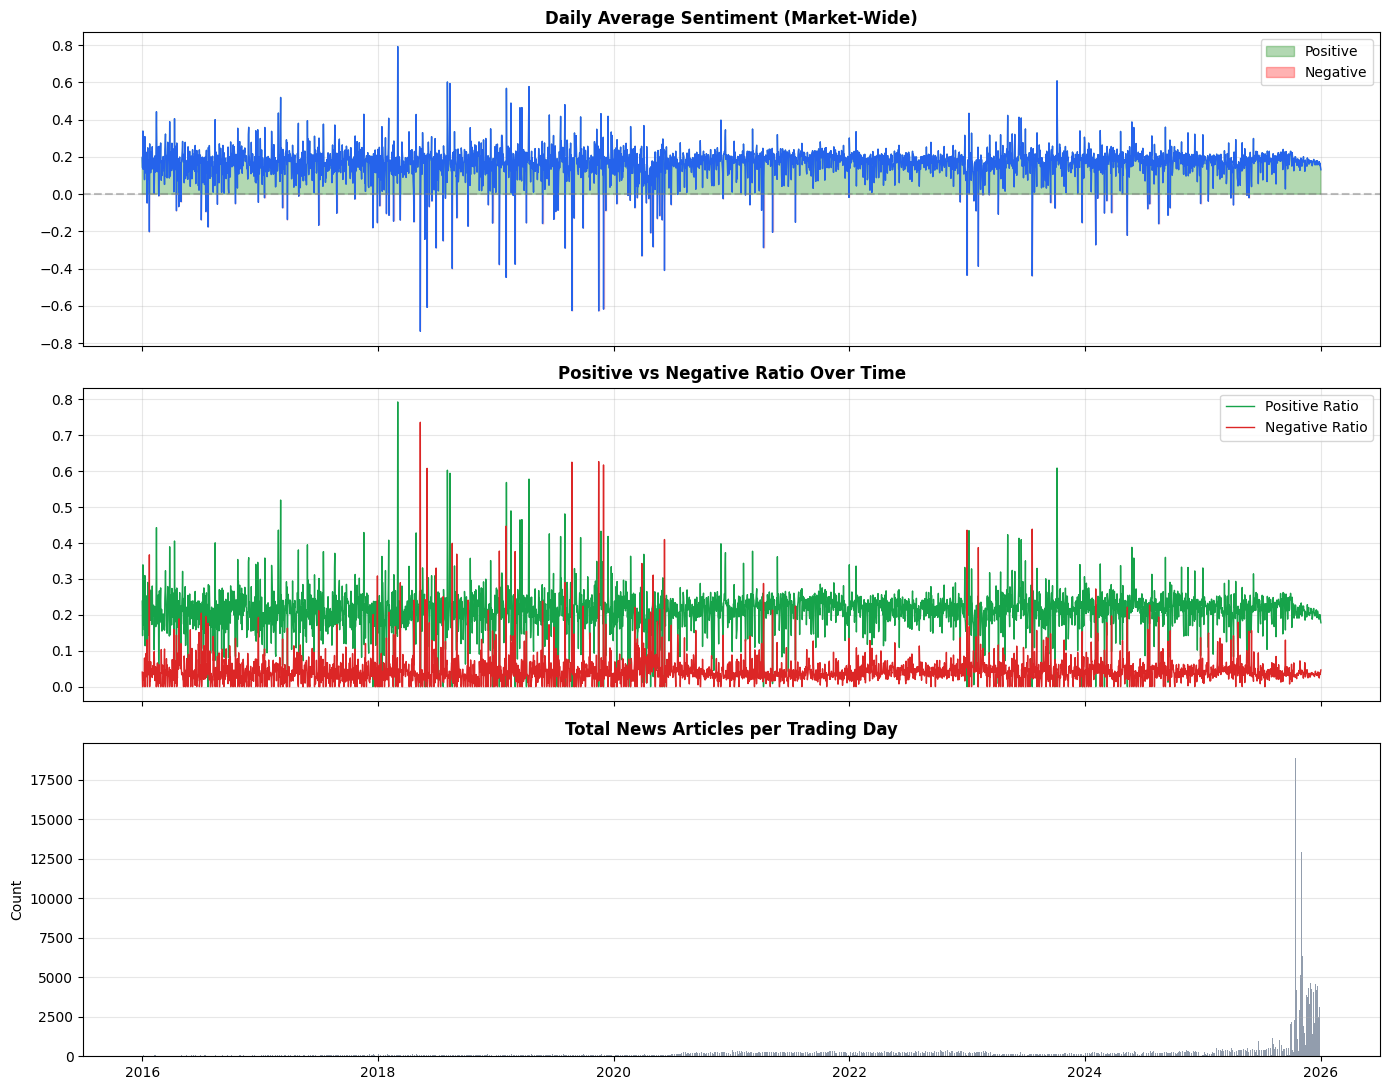

In [21]:
# Market-wide daily average sentiment over time
market_sent = daily.groupby("date")["Daily_Avg_Sentiment"].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Avg sentiment with fill
axes[0].plot(market_sent["date"], market_sent["Daily_Avg_Sentiment"], color="#2563EB", linewidth=1)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].fill_between(market_sent["date"], market_sent["Daily_Avg_Sentiment"], 0,
                     where=(market_sent["Daily_Avg_Sentiment"] > 0), alpha=0.3, color="green", label="Positive")
axes[0].fill_between(market_sent["date"], market_sent["Daily_Avg_Sentiment"], 0,
                     where=(market_sent["Daily_Avg_Sentiment"] < 0), alpha=0.3, color="red", label="Negative")
axes[0].set_title("Daily Average Sentiment (Market-Wide)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Positive vs Negative ratio
mkt2 = daily.groupby("date")[["Positive_Ratio", "Negative_Ratio"]].mean().reset_index()
axes[1].plot(mkt2["date"], mkt2["Positive_Ratio"], color="#16a34a", linewidth=1, label="Positive Ratio")
axes[1].plot(mkt2["date"], mkt2["Negative_Ratio"], color="#dc2626", linewidth=1, label="Negative Ratio")
axes[1].set_title("Positive vs Negative Ratio Over Time", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# News volume
mkt3 = daily.groupby("date")["News_Count"].sum().reset_index()
axes[2].bar(mkt3["date"], mkt3["News_Count"], color="#64748B", alpha=0.7, width=1)
axes[2].set_title("Total News Articles per Trading Day", fontweight="bold")
axes[2].set_ylabel("Count"); axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

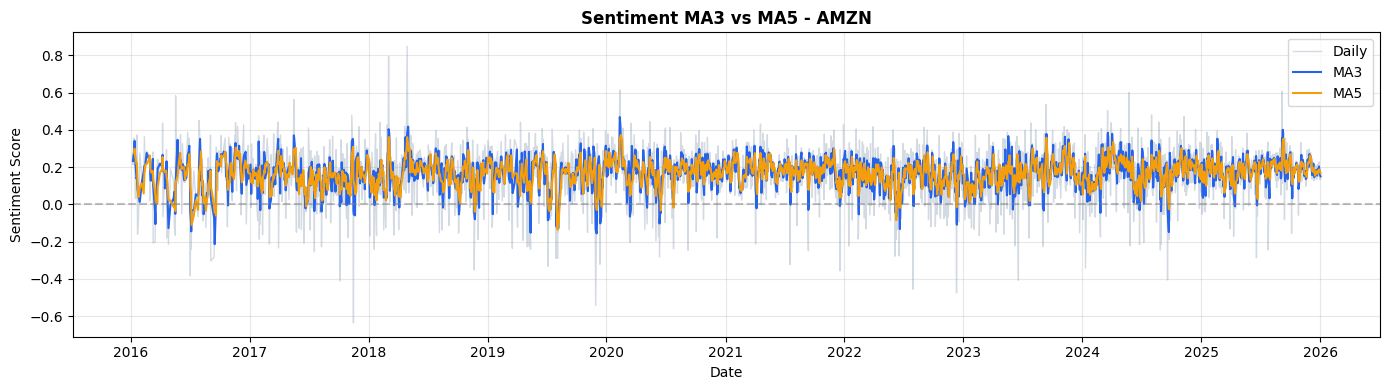

In [22]:
# Sentiment rolling MA3 vs MA5
if "ticker" in daily.columns:
    top_ticker = daily["ticker"].value_counts().index[0]
    t = daily[daily["ticker"] == top_ticker].copy()
    title = f"Sentiment MA3 vs MA5 - {top_ticker}"
else:
    t = daily.copy()
    title = "Sentiment MA3 vs MA5 - Market Wide"

plt.figure(figsize=(14, 4))
plt.plot(t["date"], t["Daily_Avg_Sentiment"], alpha=0.4, color="#94a3b8", linewidth=1, label="Daily")
plt.plot(t["date"], t["Sentiment_MA3"], color="#2563EB", linewidth=1.5, label="MA3")
plt.plot(t["date"], t["Sentiment_MA5"], color="#f59e0b", linewidth=1.5, label="MA5")
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.title(title, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

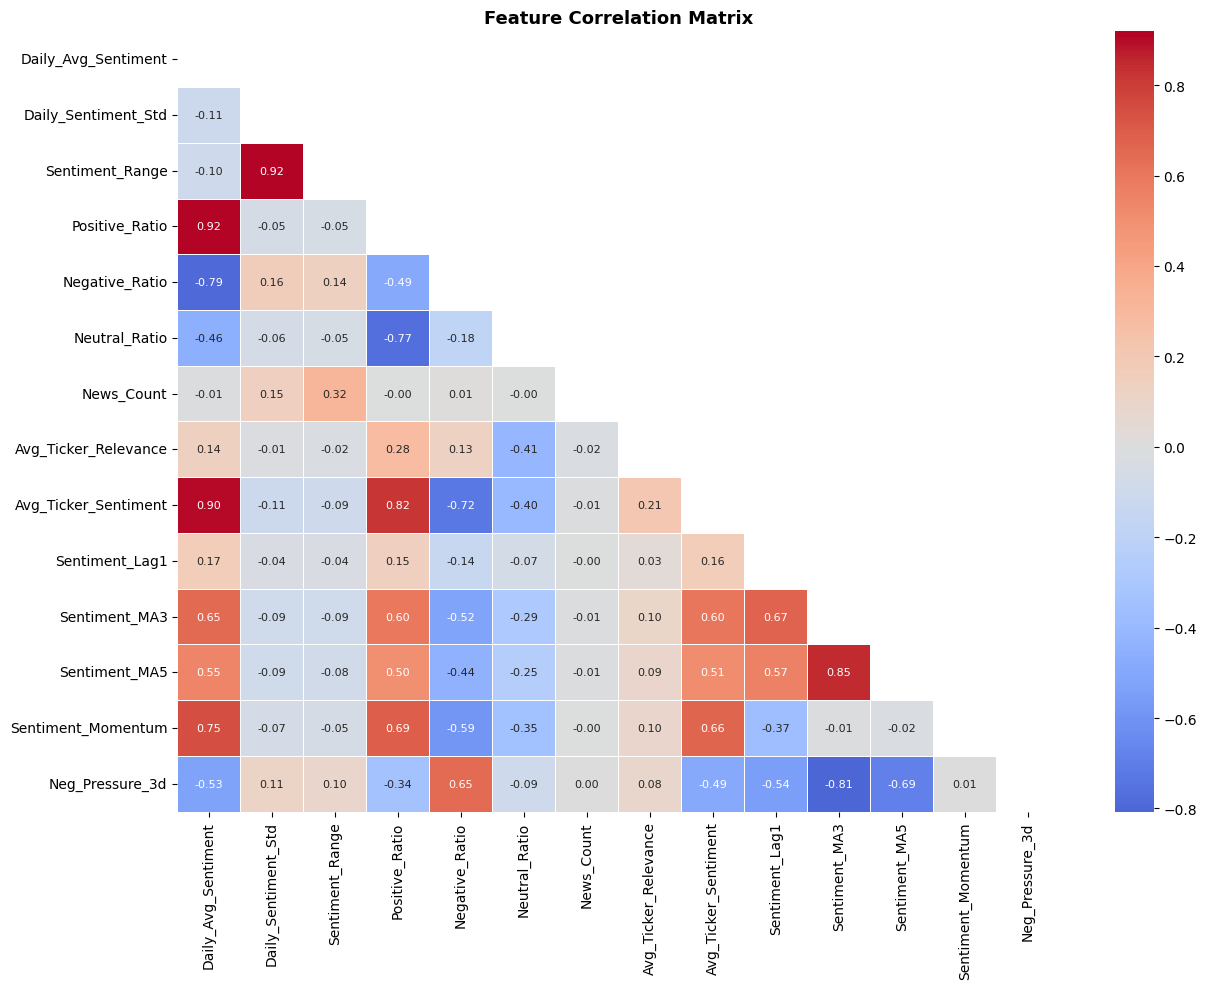

In [23]:
# Correlation heatmap of numeric features
core_feat = [
    "Daily_Avg_Sentiment", "Daily_Sentiment_Std", "Sentiment_Range",
    "Positive_Ratio", "Negative_Ratio", "Neutral_Ratio",
    "News_Count", "Avg_Ticker_Relevance", "Avg_Ticker_Sentiment",
    "Sentiment_Lag1", "Sentiment_MA3", "Sentiment_MA5",
    "Sentiment_Momentum", "Neg_Pressure_3d",
]
core_feat = [c for c in core_feat if c in daily.columns]
corr = daily[core_feat].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, annot_kws={"size": 8})
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Step:9 Feature Summary

In [24]:
core_named = [
    "Daily_Avg_Sentiment", "Daily_Sentiment_Std", "Sentiment_Range",
    "Positive_Ratio", "Negative_Ratio", "Neutral_Ratio",
    "Max_Positive", "Max_Negative",
    "News_Count", "NewsCount_Lag1",
    "Avg_Ticker_Relevance", "Avg_Ticker_Sentiment",
    "Sentiment_Lag1", "Sentiment_Lag2", "Sentiment_Lag3",
    "Sentiment_MA3", "Sentiment_MA5",
    "Sentiment_Momentum", "Sentiment_Trend", "Neg_Pressure_3d",
    "Dominant_Sentiment_Label",
]

groups = {
    "Core Sentiment"      : ["Daily_Avg_Sentiment", "Daily_Sentiment_Std", "Sentiment_Range"],
    "Ratio Features"      : ["Positive_Ratio", "Negative_Ratio", "Neutral_Ratio"],
    "Extremes"            : ["Max_Positive", "Max_Negative"],
    "News Volume"         : ["News_Count", "NewsCount_Lag1"],
    "Ticker Sentiment"    : ["Avg_Ticker_Relevance", "Avg_Ticker_Sentiment"],
    "Lag Features"        : ["Sentiment_Lag1", "Sentiment_Lag2", "Sentiment_Lag3"],
    "Rolling / MA"        : ["Sentiment_MA3", "Sentiment_MA5"],
    "Derived Signals"     : ["Sentiment_Momentum", "Sentiment_Trend", "Neg_Pressure_3d"],
    "Label (Categorical)" : ["Dominant_Sentiment_Label"],
    "Topic Features"      : [c for c in feat_cols if c not in core_named],
}

print("=" * 54)
print("    SENTIMENT FEATURE ENGINEERING SUMMARY")
print("=" * 54)
total = 0
for grp, cols in groups.items():
    present = [c for c in cols if c in daily.columns]
    print(f"  {grp:<26}: {len(present):>2} features")
    total += len(present)
print(f"  {'─'*42}")
print(f"  {'TOTAL':<26}: {total:>2} features")
print("=" * 54)

    SENTIMENT FEATURE ENGINEERING SUMMARY
  Core Sentiment            :  3 features
  Ratio Features            :  3 features
  Extremes                  :  2 features
  News Volume               :  2 features
  Ticker Sentiment          :  2 features
  Lag Features              :  3 features
  Rolling / MA              :  2 features
  Derived Signals           :  3 features
  Label (Categorical)       :  1 features
  Topic Features            : 10 features
  ──────────────────────────────────────────
  TOTAL                     : 31 features


In [25]:
# Drop rows with any NaN in numeric features (from lag/rolling warmup)
daily_clean = daily.dropna(subset=feat_cols).copy()

# Force ticker back as a plain column if groupby pushed it into the index
if "ticker" not in daily_clean.columns:
    daily_clean = daily_clean.reset_index()

daily_clean = daily_clean.reset_index(drop=True)   # clean integer index, no extra column

# Guarantee column order: ticker, date first — required by all downstream cells
_lead = ["ticker", "date"]
_rest = [c for c in daily_clean.columns if c not in _lead]
daily_clean = daily_clean[_lead + _rest]

assert list(daily_clean.columns[:2]) == ["ticker", "date"], \
    f"ticker/date not first — got {list(daily_clean.columns[:2])}"

X = daily_clean[feat_cols].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled         : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Unique tickers : {daily_clean['ticker'].nunique()}")
print(f"First 2 cols   : {list(daily_clean.columns[:2])}")

Scaled         : 301,288 rows x 30 features
Unique tickers : 500
First 2 cols   : ['ticker', 'date']


PCA: 30 features -> 15 components (90% variance retained)
   Total variance explained: 90.11%


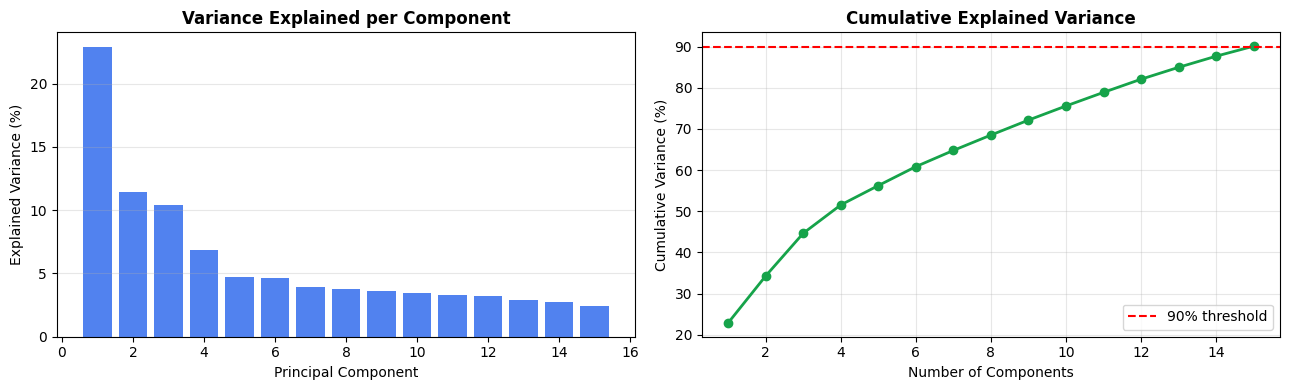

In [26]:
# Fit PCA retaining 90% variance
pca     = PCA(n_components=0.90, random_state=42)
X_pca   = pca.fit_transform(X_scaled)

print(f"PCA: {X_scaled.shape[1]} features -> {X_pca.shape[1]} components (90% variance retained)")
print(f"   Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Scree plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_ * 100, color="#2563EB", alpha=0.8)
axes[0].set_title("Variance Explained per Component", fontweight="bold")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance (%)")
axes[0].grid(axis="y", alpha=0.3)

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker="o", color="#16a34a", linewidth=2)
axes[1].axhline(90, color="red", linestyle="--", label="90% threshold")
axes[1].set_title("Cumulative Explained Variance", fontweight="bold")
axes[1].set_xlabel("Number of Components"); axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

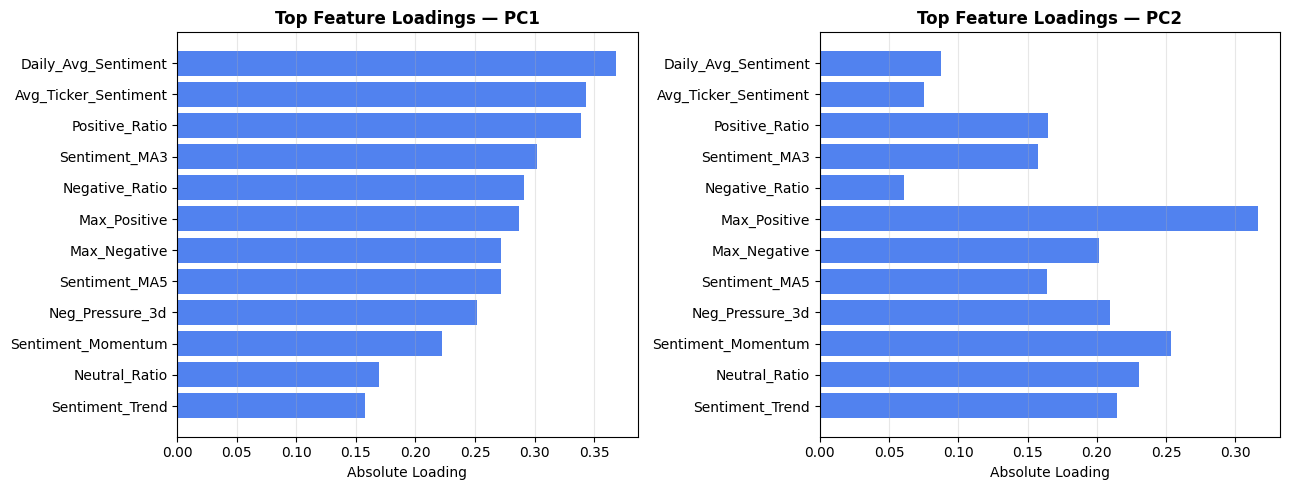

In [27]:
# Feature loadings - which original features drive PC1 and PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feat_cols,
    columns=["PC1", "PC2"]
).abs().sort_values("PC1", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = loadings[pc].head(12)
    ax.barh(top.index[::-1], top.values[::-1], color="#2563EB", alpha=0.8)
    ax.set_title(f"Top Feature Loadings — {pc}", fontweight="bold")
    ax.set_xlabel("Absolute Loading")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Attach PCA components to daily_clean
# Safe on re-run: always drop stale PC columns before re-attaching
daily_clean = daily_clean.drop(
    columns=[c for c in daily_clean.columns if c.startswith("Sentiment_PC")],
    errors="ignore",
)

# Build PCA dataframe aligned to daily_clean's index (avoids concat misalignment)
pca_cols = [f"Sentiment_PC{i+1}" for i in range(X_pca.shape[1])]
df_pca   = pd.DataFrame(X_pca, columns=pca_cols, index=daily_clean.index)
daily_clean = pd.concat([daily_clean, df_pca], axis=1)

assert list(daily_clean.columns[:2]) == ["ticker", "date"], \
    f"Expected ticker,date as first cols — got {list(daily_clean.columns[:2])}"
assert not daily_clean.columns.duplicated().any(), \
    f"Duplicate columns detected: {daily_clean.columns[daily_clean.columns.duplicated()].tolist()}"

print(f"PCA attached  : {X_pca.shape[1]} components added")
print(f"Final shape   : {daily_clean.shape[0]:,} rows x {daily_clean.shape[1]} columns")
display(daily_clean[["ticker", "date"] + pca_cols].head(5))

PCA attached  : 15 components added
Final shape   : 301,288 rows x 48 columns


,ticker,date,Sentiment_PC1,Sentiment_PC2,Sentiment_PC3,Sentiment_PC4,Sentiment_PC5,Sentiment_PC6,Sentiment_PC7,Sentiment_PC8,Sentiment_PC9,Sentiment_PC10,Sentiment_PC11,Sentiment_PC12,Sentiment_PC13,Sentiment_PC14,Sentiment_PC15
0,A,2016-05-11,2.441597,0.770997,1.626318,-0.893288,0.067911,-1.650287,0.323318,1.133427,-2.741879,-1.142278,-0.286847,-2.914919,-0.657551,0.530558,0.362902
1,A,2016-05-25,1.303532,-1.674756,-0.110385,-1.032775,0.449765,-1.309647,0.187584,0.425444,-1.163420,-0.448627,1.967365,-0.757319,-0.245294,-0.364746,-0.170935
2,A,2016-08-11,3.731712,0.185345,-0.423007,-1.979754,0.797287,0.830903,0.593481,-0.327731,0.789651,-0.235996,1.928293,-1.178600,-0.546785,2.115104,1.309556
3,A,2016-09-09,1.745181,-1.976274,-0.860848,-0.792041,-0.294430,-0.995534,-0.666454,-0.315926,-0.588631,0.505279,-0.482964,1.365711,-1.078997,0.382140,-0.727430
4,A,2016-12-01,2.634768,-1.059434,-0.361246,-1.676690,1.020766,0.072103,1.512988,-0.481999,0.845912,-0.566703,0.873528,-1.164969,0.207827,1.310609,-0.514709


## Step:11 Export single parquet file

In [29]:
# Final cleanup before export
# 1. Reset to a clean integer index (drop=True prevents old index becoming a column)
daily_clean = daily_clean.reset_index(drop=True)

# 2. Remove any duplicate columns produced by notebook re-runs
daily_clean = daily_clean.loc[:, ~daily_clean.columns.duplicated()]

# 3. Enforce ticker + date as the first two columns (merge keys for OHLCV join)
_lead = ["ticker", "date"]
_rest = [c for c in daily_clean.columns if c not in _lead]
daily_clean = daily_clean[_lead + _rest]

# 4. Lock in correct dtypes
daily_clean["date"]   = pd.to_datetime(daily_clean["date"])
daily_clean["ticker"] = daily_clean["ticker"].astype(str).str.strip().str.upper()

# 5. Sanity print
print("PRE-EXPORT SANITY CHECK")
print("")
print(f"  Shape          : {daily_clean.shape[0]:,} rows x {daily_clean.shape[1]} cols")
print(f"  Unique tickers : {daily_clean['ticker'].nunique()}")
print(f"  Date range     : {daily_clean['date'].min().date()}  →  {daily_clean['date'].max().date()}")
print(f"  Null values    : {daily_clean.isnull().sum().sum()}")
print(f"  First 2 cols   : {list(daily_clean.columns[:2])}")
print("")
print(daily_clean[["ticker", "date"]].head(8).to_string(index=False))

PRE-EXPORT SANITY CHECK

  Shape          : 301,288 rows x 48 cols
  Unique tickers : 500
  Date range     : 2016-01-07  →  2026-01-02
  Null values    : 0
  First 2 cols   : ['ticker', 'date']

ticker       date
     A 2016-05-11
     A 2016-05-25
     A 2016-08-11
     A 2016-09-09
     A 2016-12-01
     A 2016-12-23
     A 2017-02-03
     A 2017-03-09


In [30]:
# Step 11b: Save to parquet
# ── Output path: edit as needed ─────────────────────────────────────────────────
import pathlib
_nb_dir = pathlib.Path().resolve()
OUTPUT_PATH = _nb_dir / "news_sentiment.parquet"
# ─────────────────────────────────────────────────────────────────────────────────

daily_clean.to_parquet(OUTPUT_PATH, index=False, engine="pyarrow")

# Verify the file round-trips correctly
_verify = pd.read_parquet(OUTPUT_PATH)
assert list(_verify.columns[:2]) == ["ticker", "date"], \
    "Verification failed: ticker/date not first columns in saved file"
assert _verify["ticker"].notna().all(), "Verification failed: null tickers in saved file"

print(f"Saved          : {OUTPUT_PATH}")
print(f"Shape          : {_verify.shape[0]:,} rows x {_verify.shape[1]} columns")
print(f"Unique tickers : {_verify['ticker'].nunique()}")
print(f"Merge on       : ['ticker', 'date']")
print(f"\nAll {_verify.shape[1]} columns:")
for idx, c in enumerate(_verify.columns, 1):
    print(f"  {idx:>3}. {c}")

Saved          : /content/news_sentiment.parquet
Shape          : 301,288 rows x 48 columns
Unique tickers : 500
Merge on       : ['ticker', 'date']

All 48 columns:
    1. ticker
    2. date
    3. News_Count
    4. Daily_Avg_Sentiment
    5. Daily_Sentiment_Std
    6. Positive_Ratio
    7. Negative_Ratio
    8. Neutral_Ratio
    9. Max_Positive
   10. Max_Negative
   11. Sentiment_Range
   12. Dominant_Sentiment_Label
   13. Avg_Ticker_Relevance
   14. Avg_Ticker_Sentiment
   15. earnings
   16. economy_macro
   17. energy_transportation
   18. finance
   19. financial_markets
   20. life_sciences
   21. manufacturing
   22. mergers_and_acquisitions
   23. retail_wholesale
   24. technology
   25. Sentiment_Lag1
   26. Sentiment_Lag2
   27. Sentiment_Lag3
   28. Sentiment_MA3
   29. Sentiment_MA5
   30. Sentiment_Momentum
   31. Sentiment_Trend
   32. NewsCount_Lag1
   33. Neg_Pressure_3d
   34. Sentiment_PC1
   35. Sentiment_PC2
   36. Sentiment_PC3
   37. Sentiment_PC4
   38. Senti